## 1. Import Necessary Library

In [26]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold,train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

## 2. Data Collection

In [5]:
Wine_Dataset = load_wine()

In [10]:
Wine_Data_DF = pd.DataFrame(Wine_Dataset.data,columns=Wine_Dataset.feature_names)

In [11]:
Wine_Data_DF["Target"] = Wine_Dataset.target

In [12]:
Wine_Data_DF.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 3. Data Understanding

In [13]:
Wine_Data_DF.shape

(178, 14)

In [14]:
Wine_Data_DF.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [15]:
Wine_Data_DF.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Target                            int64
dtype: object

## 4. Data Prepartion

In [19]:
X =Wine_Data_DF.drop("Target",axis=1)
y=Wine_Data_DF.Target

In [20]:
X.shape,y.shape

((178, 13), (178,))

In [35]:
std_Scaler = StandardScaler() ## Normalization is Musit for KNN as result prediction based on the Sample Distance

In [23]:
scalled_X = std_Scaler.fit_transform(X)
scalled_X.shape

(178, 13)

## 5. Module Building | 6. Module Training | 7 Module Evaluation

In [24]:
X_Train,X_test,y_train,y_test = train_test_split(scalled_X,y,shuffle=True,random_state=12,stratify=y)

### when K = 3

In [31]:
KNN_Clasifier = KNeighborsClassifier(n_neighbors=3)
KNN_Clasifier.fit(X_Train,y_train)
y_predic_train = KNN_Clasifier.predict(X_Train)
print("Accuracy Score : ",round(accuracy_score(y_train,y_predic_train),4))

Accuracy Score :  0.9699


### when K = 5

In [32]:
KNN_Clasifier = KNeighborsClassifier(n_neighbors=5)
KNN_Clasifier.fit(X_Train,y_train)
y_predic_train = KNN_Clasifier.predict(X_Train)
print("Accuracy Score : ",round(accuracy_score(y_train,y_predic_train),4))

Accuracy Score :  0.9774


### when K = 7

In [33]:
KNN_Clasifier = KNeighborsClassifier(n_neighbors=7)
KNN_Clasifier.fit(X_Train,y_train)
y_predic_train = KNN_Clasifier.predict(X_Train)
print("Accuracy Score : ",round(accuracy_score(y_train,y_predic_train),4))

Accuracy Score :  0.9774


### when K = 9

In [34]:
KNN_Clasifier = KNeighborsClassifier(n_neighbors=9)
KNN_Clasifier.fit(X_Train,y_train)
y_predic_train = KNN_Clasifier.predict(X_Train)
print("Accuracy Score : ",round(accuracy_score(y_train,y_predic_train),4))

Accuracy Score :  0.9774


###  How to slect Optimal KNN Neighbour

In [78]:
k_Fold = KFold(n_splits=3,shuffle= True,random_state= 123)
CV_score_mean = []
for i in range(3,52,2):
    KNN_Clasifier = KNeighborsClassifier(n_neighbors=i)
    KNN_Clasifier.fit(X_Train,y_train)
    CV_Score = cross_val_score( KNN_Clasifier,X= X_Train,y=y_train,cv=k_Fold)
    CV_score_mean.append(CV_Score.mean().round(2))
print(CV_score_mean)
print(max(CV_score_mean))
print(CV_Score)

[np.float64(0.95), np.float64(0.94), np.float64(0.93), np.float64(0.95), np.float64(0.95), np.float64(0.97), np.float64(0.97), np.float64(0.97), np.float64(0.97), np.float64(0.97), np.float64(0.96), np.float64(0.96), np.float64(0.95), np.float64(0.94), np.float64(0.95), np.float64(0.94), np.float64(0.93), np.float64(0.93), np.float64(0.92), np.float64(0.91), np.float64(0.92), np.float64(0.93), np.float64(0.93), np.float64(0.93), np.float64(0.87)]
0.97
[0.75555556 0.93181818 0.90909091]


In [77]:
CV_score_mean.index(max(CV_score_mean))

5

In [74]:
from matplotlib import pyplot as plt

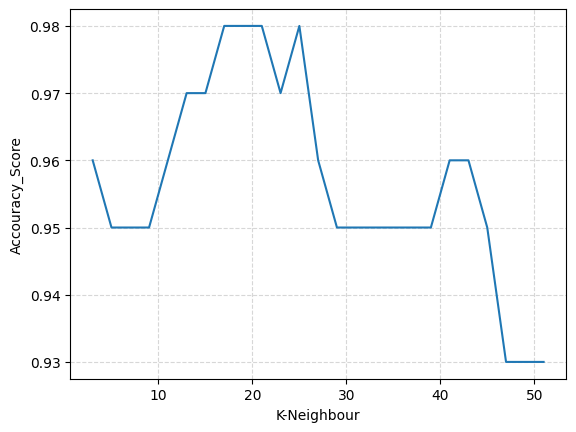

In [75]:

px = range(3,52,2)
py = CV_score_mean
plt.plot(px,py)
# 2. Loop through the data points and add text labels
plt.xlabel("K-Neighbour")
plt.ylabel("Accouracy_Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()